# JURNAL FIX MODUL 3
### NAMA : MUHAMMAD IZZUL ISLAM
### NIM : F1D02410077

In [19]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Kode di atas mengimpor tiga library utama, yaitu **`cv2` (OpenCV)** untuk pemrosesan gambar dan computer vision, **`matplotlib.pyplot`** untuk menampilkan gambar atau grafik, dan **`numpy`** untuk operasi array dan matriks numerik.

Kode di bawah digunakan untuk membaca gambar bernama `telapak.jpeg` menggunakan OpenCV dengan fungsi `cv.imread()`, lalu gambar yang awalnya berformat warna BGR (Blue, Green, Red) dikonversi menjadi grayscale menggunakan `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY`. Proses grayscale dilakukan agar gambar hanya memiliki satu channel intensitas abu-abu sehingga lebih sederhana untuk pengolahan citra. Setelah itu, gambar grayscale disimpan ke variabel `telapakGray` dan ditampilkan menggunakan `plt.imshow()` dari Matplotlib dengan `cmap="grey"` agar gambar tampil dalam warna abu-abu sesuai hasil konversi.

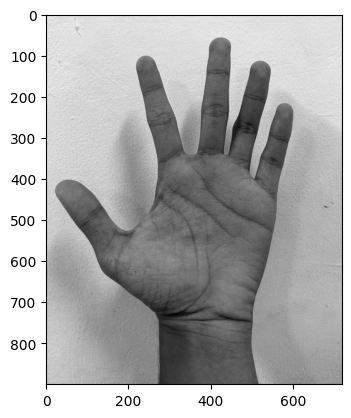

In [20]:
telapak = cv.imread('telapak.jpeg')
telapakGray = cv.cvtColor(telapak, cv.COLOR_BGR2GRAY)
plt.imshow (telapakGray, cmap = "grey")

In [21]:
def resize(citra, tinggi_baru, lebar_baru):
    tinggi_asal, lebar_asal = citra.shape[:2]  
    skala_y = tinggi_asal / tinggi_baru
    skala_x = lebar_asal / lebar_baru
 
    if len(citra.shape) == 3:
        hasil = np.zeros((tinggi_baru, lebar_baru, citra.shape[2]), dtype=np.uint8)
    else:
        hasil = np.zeros((tinggi_baru, lebar_baru), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            y_asal = min(int(i * skala_y), tinggi_asal - 1)
            x_asal = min(int(j * skala_x), lebar_asal - 1)
            hasil[i, j] = citra[y_asal, x_asal]

    return hasil

Kode di atas digunakan untuk mengubah ukuran citra menjadi tinggi dan lebar baru secara manual tanpa menggunakan fungsi bawaan OpenCV. Fungsi menerima parameter berupa citra asli, tinggi baru, dan lebar baru, kemudian menghitung skala perubahan ukuran pada sumbu `x` dan `y` berdasarkan perbandingan ukuran asli dengan ukuran tujuan. Setelah itu program membuat array kosong bernama `hasil` untuk menampung citra baru, baik untuk gambar grayscale maupun RGB. Melalui perulangan `for`, setiap piksel pada citra baru dicari pasangan piksel terdekatnya pada citra asli menggunakan metode nearest neighbor, yaitu mengambil nilai piksel berdasarkan posisi hasil perhitungan skala. Nilai piksel tersebut kemudian disalin ke citra baru hingga seluruh piksel terisi, lalu fungsi mengembalikan citra hasil resize.


Kode di bawah digunakan untuk mengubah ukuran gambar grayscale telapakGray menjadi 256×256 piksel menggunakan fungsi resize() yang telah dibuat sebelumnya. Hasil resize disimpan ke dalam variabel telapakR. Setelah proses perubahan ukuran selesai, gambar hasil resize ditampilkan menggunakan plt.imshow() dengan parameter cmap='gray' agar citra tetap ditampilkan dalam format grayscale atau abu-abu.

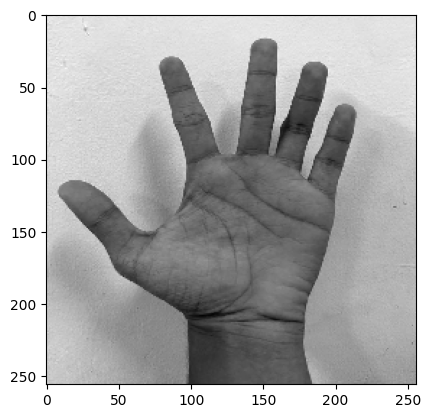

In [22]:
telapakR = resize(telapakGray, 256, 256)
plt.imshow(telapakR, cmap='gray')

In [23]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
[1/10, 1/10, 1/10],
[1/10, 1/5, 1/10],
[1/10, 1/10, 1/10]
])
# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
[1/9, 1/9, 1/9],
[1/9, 8/9, 1/9],
[1/9, 1/9, 1/9]
])
 # kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
 [-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]
], dtype=np.float32)
 # kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
 [1, 2, 1],
 [0, 0, 0],
 [-1, -2, -1]
], dtype=np.float32)
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
[-1, 0, 1],
[-1, 0, 1],
[-1, 0, 1]
], dtype=np.float32)
# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
[1, 1, 1],
[0, 0, 0],
[-1, -1, -1]
], dtype=np.float32)
# kernel roberts sumbu x / x-axis sobel kernel
robertsX = np.array([
[1, 0],
[0, -1]
], dtype=np.float32)
# kernel roberts sumbu y / y-axis sobel kernel
robertsY = np.array([
[0, 1],
[-1, 0]
], dtype=np.float32)

Kode di atas digunakan untuk membuat beberapa kernel filter yang dipakai dalam pengolahan citra digital, seperti smoothing, sharpening, dan deteksi tepi. `kernelSmoothing` digunakan untuk menghaluskan gambar dengan mengurangi noise melalui penyebaran nilai piksel di sekitarnya, sedangkan `kernelSharpening` digunakan untuk mempertajam detail gambar agar tepi objek terlihat lebih jelas. Selain itu terdapat kernel deteksi tepi yaitu `sobelX` dan `sobelY` untuk mendeteksi perubahan intensitas pada arah horizontal dan vertikal menggunakan metode Sobel, `prewittX` dan `prewittY` untuk deteksi tepi menggunakan metode Prewitt, serta `robertsX` dan `robertsY` untuk mendeteksi tepi menggunakan metode Roberts. Semua kernel disimpan dalam bentuk array NumPy yang nantinya digunakan pada proses konvolusi citra.

In [24]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

Kode di atas digunakan untuk melakukan proses konvolusi pada citra menggunakan kernel tertentu. Fungsi `convolution()` menerima parameter berupa gambar `img` dan kernel filter `kernel`, kemudian menentukan ukuran kernel dan menghitung padding agar proses konvolusi dapat dilakukan hingga tepi gambar. Fungsi `np.pad()` digunakan untuk menambahkan padding bernilai nol di sekitar citra, sedangkan `canvas` dibuat sebagai array kosong untuk menyimpan hasil konvolusi. Melalui perulangan `for`, program mengambil sebagian area citra sesuai ukuran kernel yang disebut `region`, lalu setiap elemen pada area tersebut dikalikan dengan nilai kernel dan dijumlahkan menggunakan `np.sum()`. Hasil perhitungan disimpan pada posisi piksel yang sesuai di `canvas`, kemudian fungsi mengembalikan citra hasil konvolusi.


In [25]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

Kode di atas digunakan untuk melakukan deteksi tepi pada citra dengan memanfaatkan dua kernel, yaitu kernel arah horizontal (`kernelx`) dan vertikal (`kernely`). Fungsi `edge()` terlebih dahulu memanggil fungsi `convolution()` untuk menghitung gradien citra pada sumbu `x` yang disimpan di variabel `gx` dan gradien pada sumbu `y` yang disimpan di variabel `gy`. Setelah itu dibuat array `canvas` untuk menampung hasil deteksi tepi, kemudian nilai absolut dari `gx` dan `gy` dijumlahkan agar seluruh perubahan intensitas tepi dapat terlihat jelas. Hasilnya kemudian dinormalisasi ke rentang 0–255 agar sesuai dengan format citra digital, lalu fungsi `np.clip()` digunakan untuk memastikan nilai piksel tidak melebihi batas tersebut sebelum dikonversi menjadi tipe data `uint8` dan dikembalikan sebagai citra hasil deteksi tepi.


Kode di bawah digunakan untuk melakukan deteksi tepi pada citra `telapakR` menggunakan metode Prewitt dengan kernel `prewittX` dan `prewittY`. Fungsi `edge()` akan menghitung perubahan intensitas piksel pada arah horizontal dan vertikal sehingga bagian tepi objek pada gambar dapat terlihat lebih jelas. Hasil deteksi tepi disimpan ke dalam variabel `dTepi`, kemudian ditampilkan menggunakan `plt.imshow()` dengan `cmap='gray'` agar citra hasil deteksi tetap ditampilkan dalam format grayscale.

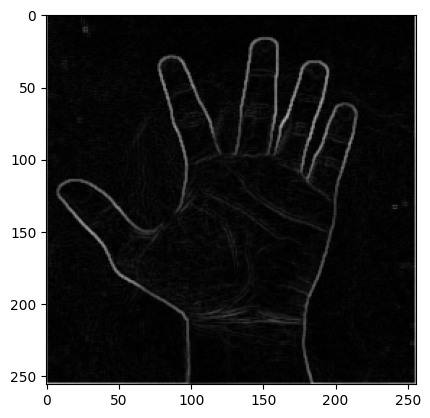

In [26]:
dTepi = edge(telapakR, prewittX, prewittY)
plt.imshow(dTepi, cmap = 'gray')

In [27]:
def thresholding (image, threshold):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype = image.dtype)
    for i in range(h):
        for j in range(w):
            if image[i, j] > threshold:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0
    return hasil

Kode di atas digunakan untuk melakukan proses thresholding pada citra, yaitu teknik untuk mengubah citra grayscale menjadi citra biner berdasarkan nilai ambang tertentu (threshold). Fungsi `thresholding()` menerima input berupa gambar dan nilai threshold, kemudian membaca ukuran gambar dan membuat array kosong `hasil` dengan ukuran yang sama. Selanjutnya dilakukan perulangan pada setiap piksel, di mana jika nilai piksel lebih besar dari threshold maka nilainya diubah menjadi 255 (putih), sedangkan jika lebih kecil atau sama dengan threshold maka diubah menjadi 0 (hitam). Hasil akhir berupa citra biner dikembalikan sebagai output fungsi.

Kode di bawah digunakan untuk menerapkan proses thresholding pada citra hasil deteksi tepi `dTepi` dengan nilai ambang sebesar 15. Fungsi `thresholding()` akan mengubah citra menjadi citra biner, yaitu piksel yang memiliki nilai lebih besar dari 15 akan diubah menjadi 255 (putih) sedangkan piksel yang bernilai kurang dari atau sama dengan 15 akan diubah menjadi 0 (hitam), sehingga hanya bagian tepi yang paling signifikan yang tetap terlihat jelas. Hasilnya disimpan dalam variabel `tepiThres`, kemudian ditampilkan menggunakan `plt.imshow()` dengan `cmap='gray'` agar tetap ditampilkan dalam skala abu-abu.

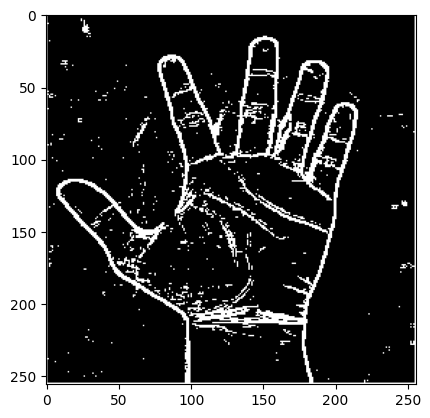

In [28]:
Thres = thresholding(dTepi, 15) 
plt.imshow(Thres, cmap = 'gray')

Text(0.5, 1.0, 'Threshold')

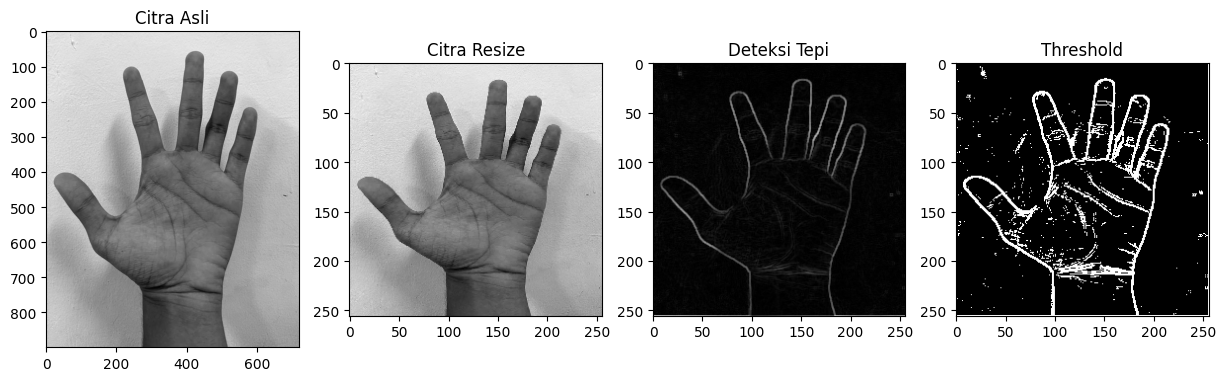

In [29]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(telapakGray, cmap = 'gray')
plt.title('Citra Asli')

plt.subplot(1, 4, 2)
plt.imshow(telapakR, cmap = 'gray')
plt.title('Citra Resize')

plt.subplot(1, 4, 3)
plt.imshow(dTepi, cmap = 'gray')
plt.title('Deteksi Tepi')

plt.subplot(1, 4, 4)
plt.imshow(Thres, cmap = 'gray')
plt.title('Threshold')

In [30]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape

    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):

            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):

                        if kernel[k, l] == 1:
                            hasil[
                                i + k - center,
                                j + l - center
                            ] = 255

            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil

Kode di atas digunakan untuk melakukan operasi morfologi citra yaitu dilasi (dilation), yang berfungsi untuk memperbesar atau menebalkan area objek putih pada citra biner. Fungsi `dilasi()` menerima input berupa gambar biner dan kernel structuring element, kemudian mengambil ukuran gambar dan ukuran kernel untuk menentukan titik pusat. Proses dilasi dilakukan dengan memeriksa setiap piksel citra, jika nilai piksel bernilai 255 (putih), maka seluruh area di sekitar piksel tersebut akan diperluas sesuai bentuk kernel dengan cara mengubah piksel tetangganya menjadi 255 pada citra hasil. Jika tidak memenuhi kondisi tersebut, nilai piksel akan diisi 0 jika belum pernah diubah. Hasil akhir berupa citra yang objek putihnya terlihat lebih tebal atau melebar, lalu dikembalikan oleh fungsi.

In [32]:
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape

    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):

            cocok = True

            for k in range(k_height):
                for l in range(k_width):

                    if (
                        kernel[k, l] == 1
                        and image[
                            i + k - center,
                            j + l - center
                        ] == 0
                    ):
                        cocok = False
                        break

                if not cocok:
                    break

            if cocok:
                hasil[i, j] = 255

    return hasil

Kode di atas digunakan untuk melakukan operasi morfologi citra yaitu erosi (erosion), yang berfungsi untuk mengurangi atau menipiskan area objek putih pada citra biner. Fungsi `erosi()` menerima input berupa citra biner dan kernel structuring element, kemudian mengambil ukuran gambar dan ukuran kernel untuk menentukan titik pusat. Proses erosi dilakukan dengan memeriksa setiap piksel citra dan mencocokkan seluruh bentuk kernel pada area sekitarnya. Jika semua posisi pada kernel yang bernilai 1 juga bernilai 255 pada citra (artinya cocok sepenuhnya), maka piksel pada posisi tersebut tetap diberi nilai 255, tetapi jika ada satu saja ketidaksesuaian (piksel 0 pada area yang seharusnya 1), maka piksel tersebut dianggap tidak cocok dan tidak akan diaktifkan. Hasil akhir berupa citra yang objek putihnya menjadi lebih kecil atau menyusut, kemudian dikembalikan oleh fungsi.

In [31]:
kernel_diamond = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=np.uint8)

kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

kernel_x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

kernel_3 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

kernel_5 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.uint8)



Kode di atas digunakan untuk mendefinisikan beberapa kernel structuring element yang akan digunakan dalam operasi morfologi citra, khususnya pada proses seperti dilasi atau erosi. Setiap kernel berupa matriks NumPy yang berisi nilai 0 dan 1, di mana nilai 1 menunjukkan area yang aktif dalam pembentukan bentuk tertentu. `kernel_diamond` membentuk pola seperti berlian, `kernel_cross` membentuk pola tanda tambah (+), dan `kernel_x` membentuk pola silang (X) untuk mempengaruhi piksel di arah diagonal. Selain itu, `kernel_3` dan `kernel_5` merupakan kernel berbentuk kotak penuh berukuran 3×3 dan 5×5 yang digunakan untuk memperluas atau mempengaruhi area tetangga secara merata. Kernel-kernel ini nantinya digunakan sebagai acuan struktur dalam proses morfologi untuk memodifikasi bentuk objek pada citra.

In [33]:
def opening(image, kernel):
    return dilasi(erosi(image, kernel), kernel)


def closing(image, kernel):
    return erosi(dilasi(image, kernel), kernel)

Kode di atas digunakan untuk melakukan operasi morfologi citra lanjutan yaitu **opening** dan **closing** yang merupakan kombinasi dari operasi erosi dan dilasi. Fungsi `opening()` dilakukan dengan cara terlebih dahulu menerapkan erosi pada citra untuk menghilangkan noise kecil atau objek kecil, kemudian hasilnya diperbesar kembali menggunakan dilasi sehingga bentuk objek utama tetap terjaga tetapi gangguan kecil hilang. Sedangkan fungsi `closing()` dilakukan dengan kebalikan proses tersebut, yaitu diawali dengan dilasi untuk menutup lubang kecil atau celah pada objek, lalu dilanjutkan dengan erosi untuk mengembalikan ukuran objek mendekati bentuk aslinya. Kedua fungsi ini sangat berguna dalam pengolahan citra biner untuk memperbaiki kualitas bentuk objek agar lebih bersih dan utuh.

In [34]:
def thining(img):
    binary = (img > 0).astype(np.uint8)

    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height - 1):
            for j in range(1, width - 1):

                P1 = binary[i, j]

                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        # STEP 2
        for i in range(1, height - 1):
            for j in range(1, width - 1):

                P1 = binary[i, j]

                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

Kode di atas digunakan untuk melakukan proses **thinning (penipisan citra biner)**, yaitu teknik morfologi yang bertujuan untuk mengurangi ketebalan objek putih pada gambar tanpa menghilangkan bentuk atau konektivitasnya. Pada awalnya, citra diubah menjadi biner dengan nilai 0 dan 1, lalu algoritma bekerja secara iteratif menggunakan dua tahap utama (STEP 1 dan STEP 2) hingga tidak ada lagi perubahan (`changed = False`). Pada setiap piksel yang bernilai 1, sistem mengambil 8 tetangga (P2 sampai P9) untuk menganalisis struktur sekitarnya, kemudian menghitung jumlah tetangga aktif serta jumlah transisi dari 0 ke 1 pada urutan piksel sekeliling. Jika memenuhi beberapa syarat tertentu (jumlah tetangga, transisi tunggal, dan kondisi konektivitas), maka piksel tersebut ditandai untuk dihapus. Proses ini dilakukan berulang pada dua tahap dengan kondisi berbeda untuk menjaga bentuk objek tetap utuh. Iterasi terus berjalan sampai tidak ada piksel yang dihapus lagi, lalu hasil akhir dikonversi kembali menjadi citra dengan skala 0–255.

In [35]:
def thickening(img, kernel, iterasi=1):
    hasil = img.copy()

    for _ in range(iterasi):
        hasil = dilasi(hasil, kernel)

    return hasil

Kode di atas digunakan untuk melakukan proses **thickening (penebalan citra biner)**, yaitu operasi morfologi yang bertujuan untuk memperbesar atau menebalkan objek pada gambar. Fungsi `thickening()` menerima input berupa citra `img`, kernel structuring element, dan jumlah iterasi yang menentukan seberapa banyak proses dilasi akan dilakukan. Di dalam fungsi, citra asli disalin terlebih dahulu ke variabel `hasil` agar data awal tidak berubah. Kemudian dilakukan perulangan sebanyak `iterasi`, di mana setiap iterasi menerapkan operasi **dilasi** menggunakan kernel yang diberikan, sehingga objek putih pada citra akan semakin melebar. Setelah semua iterasi selesai, hasil akhir dikembalikan sebagai citra yang sudah mengalami penebalan.

In [36]:
dilasi3 = dilasi(Thres, kernel_3)
erosi3 = erosi(Thres,kernel_3)
opening3 = opening(Thres, kernel_3)
closing3 = closing(Thres, kernel_3)
thin3 = thining(Thres)
thick3 = thickening(Thres,kernel_3,iterasi=1)
gm3 = dilasi3 - erosi3

Kode di atas digunakan untuk menerapkan berbagai operasi morfologi citra pada gambar biner `Thres` menggunakan kernel berukuran 3×3, kemudian menyimpan hasil masing-masing operasi ke dalam variabel yang berbeda. `dilasi3` digunakan untuk memperbesar objek putih pada citra, sedangkan `erosi3` digunakan untuk mengecilkan atau menipiskan objek. Selanjutnya `opening3` merupakan kombinasi erosi diikuti dilasi untuk menghilangkan noise kecil, dan `closing3` merupakan kombinasi dilasi diikuti erosi untuk menutup celah kecil pada objek. Selain itu, `thin3` digunakan untuk melakukan penipisan objek (thinning) agar bentuknya menjadi lebih ramping, sedangkan `thick3` melakukan penebalan objek menggunakan operasi dilasi sebanyak satu kali iterasi. Terakhir, `gm3` dihitung sebagai selisih antara hasil dilasi dan erosi, yang dapat digunakan untuk menonjolkan bagian tepi atau struktur tertentu pada citra.

Kode di bawah digunakan untuk menampilkan hasil berbagai operasi morfologi citra dalam satu tampilan menggunakan Matplotlib. Pertama, `plt.figure(figsize=(16, 8))` digunakan untuk menentukan ukuran canvas agar semua hasil dapat terlihat jelas. Kemudian `plt.subplot(2, 4, n)` membagi tampilan menjadi 2 baris dan 4 kolom sehingga setiap hasil operasi dapat ditampilkan pada posisi yang berbeda. Masing-masing subplot menampilkan hasil dari operasi morfologi seperti dilasi (`dilasi3`), erosi (`erosi3`), opening (`opening3`), closing (`closing3`), thinning (`thin3`), thickening (`thick3`), dan morphological gradient (`gm3`) menggunakan `plt.imshow()` dengan mode grayscale (`cmap='gray'`). Setiap gambar diberi judul sesuai jenis operasinya dan `plt.axis('off')` digunakan untuk menghilangkan sumbu agar tampilan lebih rapi dan fokus pada hasil citra.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

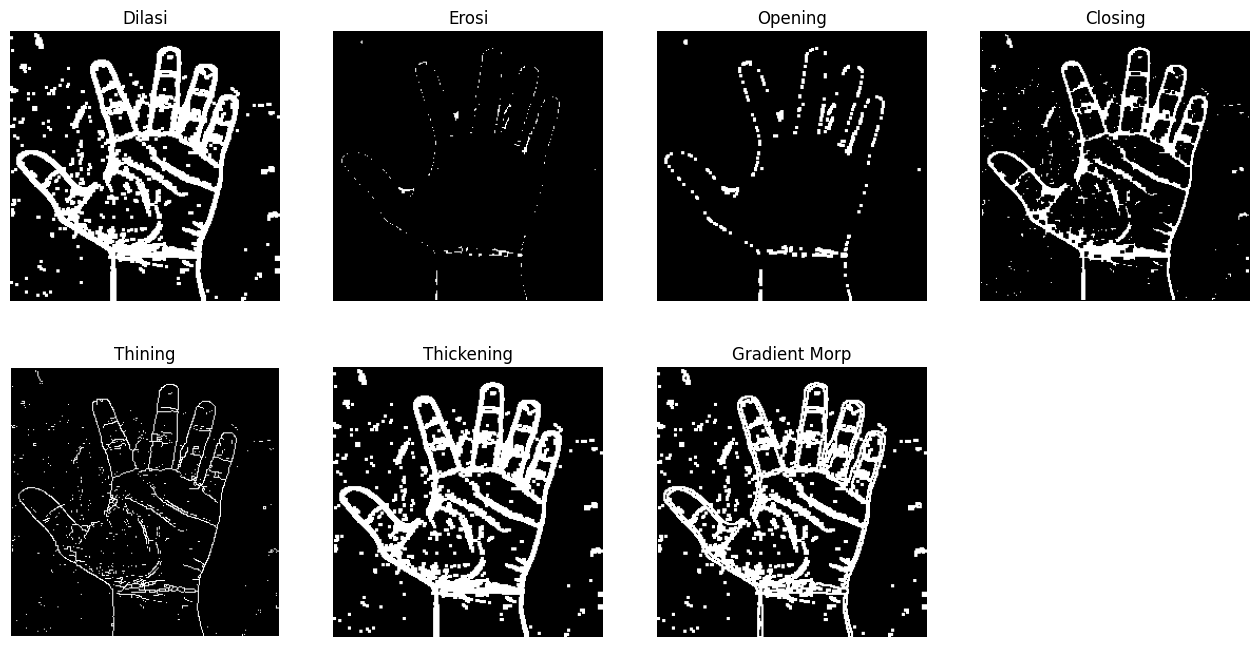

In [37]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(dilasi3, cmap = 'gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(erosi3, cmap = 'gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(opening3, cmap = 'gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(closing3, cmap = 'gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(thin3, cmap = 'gray')
plt.title('Thining')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(thick3, cmap = 'gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(gm3, cmap = 'gray')
plt.title('Gradient Morp')
plt.axis('off')

In [38]:
dilasi5 = dilasi(Thres, kernel_5)
erosi5 = erosi(Thres,kernel_5)
opening5 = opening(Thres, kernel_5)
closing5 = closing(Thres, kernel_5)
thin5 = thining(Thres)
thick5 = thickening(Thres,kernel_5,iterasi=1)
gm5 = dilasi5 - erosi5

Kode di atas digunakan untuk menerapkan berbagai operasi morfologi citra pada gambar biner `Thres` menggunakan kernel berukuran 5×5. Pertama, `dilasi5` digunakan untuk memperbesar atau menebalkan objek pada citra, sedangkan `erosi5` digunakan untuk mengecilkan atau mengikis objek. Selanjutnya, `opening5` merupakan hasil kombinasi erosi diikuti dilasi yang berfungsi untuk menghilangkan noise kecil, sedangkan `closing5` merupakan kombinasi dilasi diikuti erosi yang berguna untuk menutup celah kecil pada objek. Selain itu, `thin5` digunakan untuk melakukan penipisan objek agar bentuknya menjadi lebih ramping, dan `thick5` digunakan untuk menebalkan objek dengan satu kali proses dilasi menggunakan kernel 5×5. Terakhir, `gm5` merupakan hasil selisih antara dilasi dan erosi yang merepresentasikan morphological gradient untuk menonjolkan bagian tepi atau batas objek pada citra.

Kode di bawah digunakan untuk menampilkan hasil berbagai operasi morfologi citra yang dilakukan pada gambar biner `Thres` menggunakan kernel berukuran 5×5. Pertama, `plt.figure(figsize=(16, 8))` digunakan untuk mengatur ukuran tampilan agar hasil gambar lebih jelas. Kemudian `plt.subplot(2, 4, n)` membagi tampilan menjadi 2 baris dan 4 kolom sehingga setiap hasil operasi ditampilkan pada posisi yang berbeda dalam satu figure. Setiap subplot menampilkan hasil operasi seperti dilasi (`dilasi5`), erosi (`erosi5`), opening (`opening5`), closing (`closing5`), thinning (`thin5`), thickening (`thick5`), dan morphological gradient (`gm5`) menggunakan `plt.imshow()` dengan skala abu-abu (`cmap='gray'`). Setiap gambar diberi judul sesuai operasinya dan `plt.axis('off')` digunakan untuk menghilangkan sumbu agar tampilan lebih bersih dan fokus pada hasil citra.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

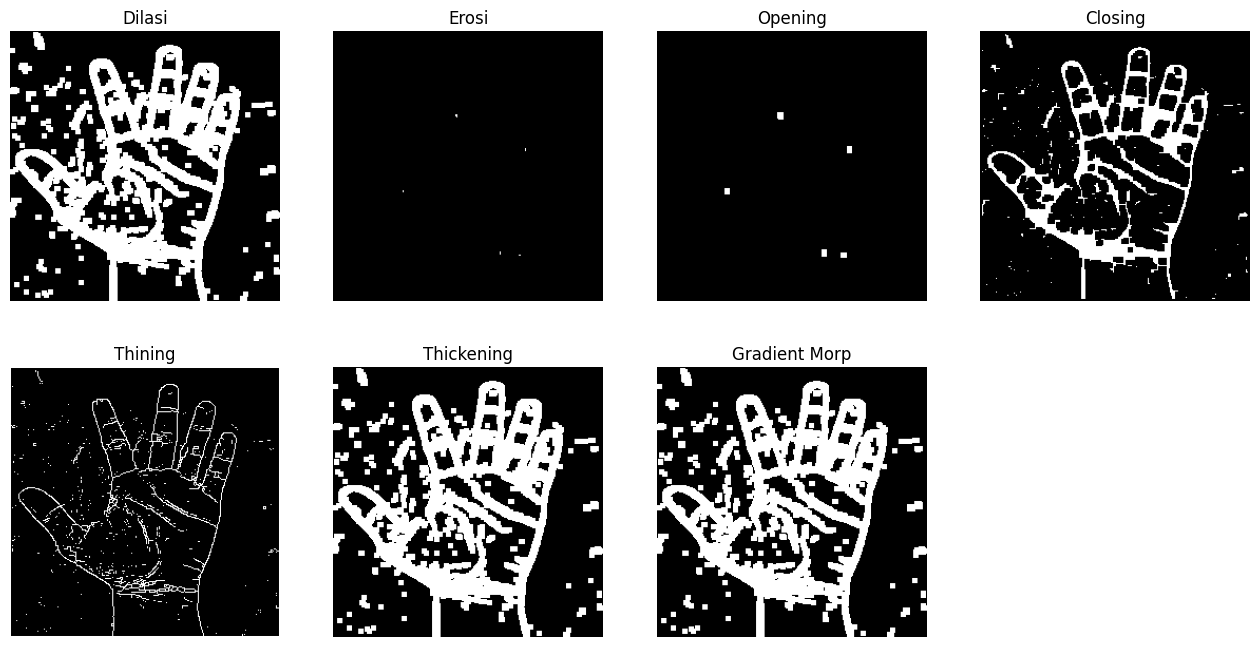

In [39]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(dilasi5, cmap = 'gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(erosi5, cmap = 'gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(opening5, cmap = 'gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(closing5, cmap = 'gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(thin5, cmap = 'gray')
plt.title('Thining')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(thick5, cmap = 'gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(gm5, cmap = 'gray')
plt.title('Gradient Morp')
plt.axis('off')

In [40]:
Opclos = closing(opening3,kernel_3)
Closop = opening(closing3,kernel_3)
Opdil = dilasi(opening3, kernel_3) 
Closer = erosi(closing3, kernel_3) 

Kode di atas digunakan untuk melakukan kombinasi lanjutan dari operasi morfologi citra pada hasil sebelumnya menggunakan kernel 3×3. `Opclos` merupakan hasil dari operasi closing yang diterapkan pada citra yang sudah di-opening (`opening3`), sehingga bertujuan untuk menutup kembali celah kecil setelah noise dihilangkan. `Closop` adalah kebalikannya, yaitu opening yang diterapkan pada hasil closing (`closing3`) untuk menghaluskan kembali struktur setelah penutupan lubang. Selanjutnya `Opdil` merupakan hasil dilasi dari citra `opening3` untuk memperbesar area objek setelah proses pembersihan noise, sedangkan `Closer` adalah hasil erosi dari citra `closing3` untuk mengikis kembali area objek setelah proses penutupan. Kombinasi operasi ini digunakan untuk melihat efek lanjutan morfologi dalam memperbaiki atau memodifikasi struktur objek pada citra.

Kode di bawah digunakan untuk menampilkan hasil kombinasi lanjutan operasi morfologi citra dalam satu tampilan menggunakan Matplotlib. Pertama, `plt.figure(figsize=(8, 8))` digunakan untuk menentukan ukuran figure agar hasil gambar terlihat lebih rapi. Kemudian `plt.subplot(2, 2, n)` membagi tampilan menjadi 2 baris dan 2 kolom, sehingga setiap hasil operasi ditampilkan pada posisi yang berbeda. Masing-masing subplot menampilkan hasil kombinasi operasi seperti `Opclos` (opening diikuti closing), `Closop` (closing diikuti opening), `Opdil` (opening diikuti dilasi), dan `Closer` (closing diikuti erosi) menggunakan `plt.imshow()` dengan skala abu-abu (`cmap='gray'`). Setiap gambar diberi judul sesuai jenis kombinasinya dan `plt.axis('off')` digunakan untuk menghilangkan sumbu agar tampilan lebih bersih. Terakhir, `plt.tight_layout()` digunakan untuk merapikan jarak antar subplot agar tidak saling bertumpuk, lalu `plt.show()` menampilkan seluruh hasil pada layar.

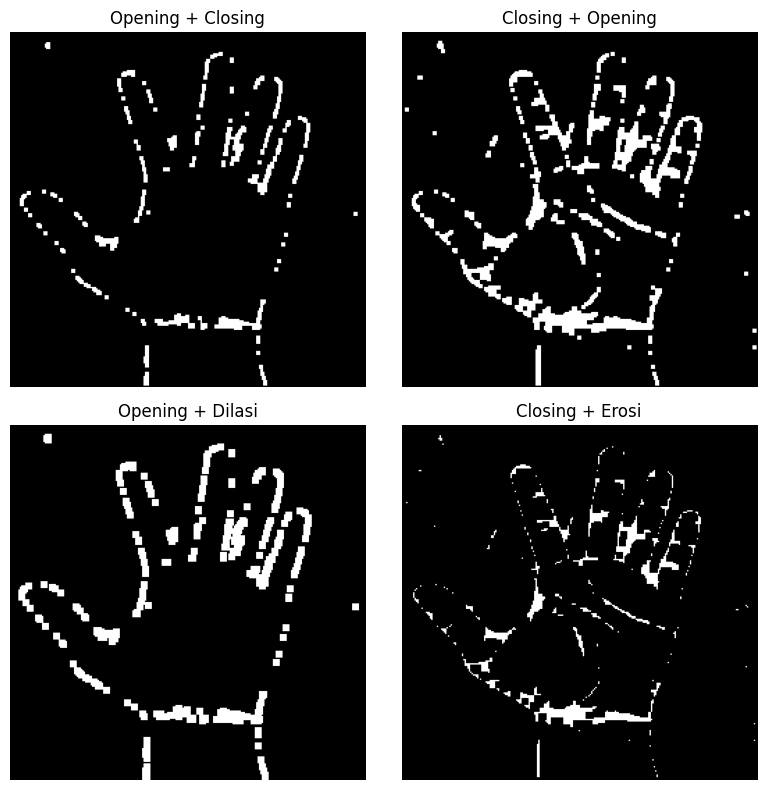

In [42]:
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.imshow(Opclos, cmap='gray')
plt.title('Opening + Closing')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(Closop, cmap='gray')
plt.title('Closing + Opening')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(Opdil, cmap='gray')
plt.title('Opening + Dilasi')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(Closer, cmap='gray')
plt.title('Closing + Erosi')
plt.axis('off')

plt.tight_layout()
plt.show()

Kode di bawah digunakan untuk melakukan proses pengolahan citra secara bertahap mulai dari deteksi tepi hingga penebalan dan deteksi ulang. Pertama, `sob2` merupakan hasil deteksi tepi pada citra `telapakR` menggunakan metode Sobel dengan kernel `sobelX` dan `sobelY`. Hasil ini kemudian diproses dengan `thresholding()` menggunakan nilai ambang 25 untuk menghasilkan citra biner pada variabel `t2`, sehingga hanya tepi yang kuat yang dipertahankan. Selanjutnya, `thickening()` diterapkan pada `t2` dengan kernel 3×3 sebanyak 2 iterasi untuk menebalkan kembali struktur tepi agar lebih jelas dan menyatu. Setelah itu, dilakukan kembali proses deteksi tepi menggunakan Sobel pada hasil `thick3` yang disimpan dalam variabel `tepi` untuk mempertegas batas objek setelah proses morfologi sebelumnya. Terakhir, citra hasil deteksi tepi tersebut ditampilkan menggunakan `plt.imshow()` dalam mode grayscale.

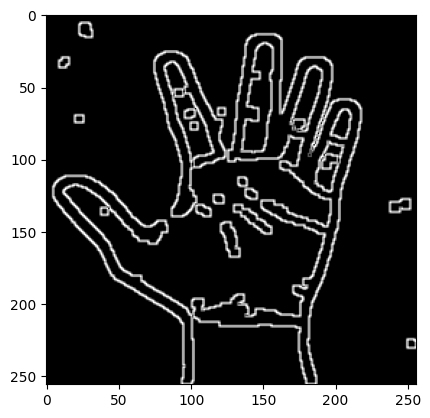

In [43]:
sob2   = edge(telapakR,sobelX, sobelY)
t2 = thresholding(sob2,25)
thick3 = thickening(t2,kernel_3,iterasi=2)
tepi = edge(thick3, sobelX, sobelY)
plt.imshow(tepi, cmap= 'gray')
plt.show()

# ANALISIS

1. lakukan analisis terhadap
perbedaan  yang  terlihat  antara
citra  hasil  morfologi  dan  citra  asli
sebelum  proses  morfologi
dilakukan!

Perbedaan yang terlihat antara citra asli sebelum proses morfologi dan citra hasil morfologi sangat signifikan pada bentuk, struktur, dan ketegasan objek. Pada citra asli, terutama setelah grayscale atau threshold awal, biasanya masih terdapat noise, tepi yang kurang tegas, serta bentuk objek yang belum sepenuhnya bersih atau tersegmentasi dengan baik. Selain itu, detail kecil yang tidak relevan juga masih ikut muncul sehingga membuat struktur citra terlihat lebih “kasar”.

Setelah dilakukan proses morfologi seperti dilasi, erosi, opening, dan closing, citra menjadi jauh lebih terstruktur. Dilasi membuat objek tampak lebih tebal dan menyatu, sedangkan erosi mengecilkan objek dan menghilangkan noise kecil. Opening membantu menghapus noise tanpa merusak bentuk utama objek, sementara closing menutup celah atau lubang kecil pada objek sehingga bentuknya menjadi lebih solid. Kombinasi operasi seperti thinning dan thickening juga mengubah representasi objek: thinning menghasilkan bentuk yang lebih ramping seperti skeleton, sedangkan thickening mempertebal struktur agar lebih jelas.

Secara keseluruhan, citra hasil morfologi terlihat lebih bersih, lebih halus, dan lebih mudah dianalisis dibandingkan citra asli. Detail yang tidak penting berkurang, sementara struktur utama objek menjadi lebih tegas dan konsisten, sehingga lebih cocok untuk tahap analisis lanjutan seperti deteksi bentuk atau ekstraksi fitur.

 2. lakukan analisis
terhadap  perbedaan  yang  terlihat
antara  citra  hasil  morfologi
menggunakan kernel 5×5 dan kernel
3×3.  Perhatikan  perubahan  yang
terjadi  pada  ketebalan  objek,  detail
citra,  tingkat  noise,  serta  bentuk
objek  setelah  proses  morfologi
dilakukan.


Perbedaan utama antara hasil morfologi menggunakan kernel 3×3 dan 5×5 terlihat pada tingkat pengaruh operasi terhadap struktur citra. Pada kernel 3×3, efek morfologi masih relatif ringan sehingga perubahan pada objek tidak terlalu ekstrem. Ketebalan objek bertambah atau berkurang secara halus, detail citra masih cukup terjaga, dan noise kecil dapat dikurangi tanpa menghilangkan terlalu banyak informasi penting. Karena area jangkauan kernel lebih kecil, bentuk objek juga tetap lebih mendekati bentuk aslinya sehingga hasilnya lebih natural.

Sebaliknya, pada kernel 5×5, pengaruh operasi morfologi menjadi lebih kuat karena area tetangga yang diproses lebih luas. Akibatnya, objek cenderung menjadi lebih tebal pada operasi dilasi atau lebih menyusut pada erosi dibandingkan kernel 3×3. Detail kecil pada citra lebih banyak hilang karena ikut “terserap” oleh struktur kernel yang lebih besar. Noise juga lebih efektif dihilangkan, tetapi konsekuensinya beberapa detail penting bisa ikut terhapus. Dari sisi bentuk, objek dapat mengalami perubahan yang lebih signifikan seperti menjadi lebih halus, lebih menyatu, atau kehilangan bagian-bagian kecil pada tepi.

Secara keseluruhan, kernel 3×3 lebih cocok untuk menjaga detail sambil tetap membersihkan noise ringan, sedangkan kernel 5×5 lebih efektif untuk pembersihan kuat dan perubahan struktur yang lebih drastis, tetapi dengan risiko hilangnya detail halus pada citra.

3. Lakukan kombinasi dua operasi morfologi citrasecara berurutan, seperti opening– closingatau erosi–dilasi, menggunakan kernel yangtelah ditentukan. Tampilkan hasil citra darisetiap kombinasi proses, kemudian lakukananalisis terhadap perubahan yang terjadidibandingkan dengan hasil operasi morfologitunggal dan citra asli. Perhatikan pengaruhkombinasi operasi terhadap pengurangannoise, bentuk objek, ketebalan objek, sertakejelasan batas objek pada citra

Hasil citra dari setiap kombinasi biasanya menunjukkan perbedaan yang lebih stabil dibandingkan operasi tunggal. Pada operasi tunggal seperti hanya erosi atau dilasi, perubahan bentuk cenderung ekstrem ke satu arah (hanya mengecil atau hanya membesar). Namun pada kombinasi operasi, perubahan tersebut menjadi lebih seimbang. Noise pada citra dapat berkurang lebih efektif, karena opening membantu menghapus noise kecil dan closing membantu memperbaiki lubang kecil pada objek. Bentuk objek menjadi lebih konsisten dan tidak terlalu terdistorsi, sementara ketebalan objek lebih terkontrol karena efek operasi pertama sebagian dikoreksi oleh operasi kedua.

Dari sisi kejelasan batas objek, kombinasi operasi morfologi menghasilkan tepi yang lebih bersih dan lebih tegas dibandingkan citra asli maupun operasi tunggal. Hal ini terjadi karena noise sudah diminimalkan dan struktur objek sudah diperbaiki secara bertahap. Secara keseluruhan, kombinasi operasi morfologi memberikan hasil yang lebih optimal untuk memperbaiki kualitas citra, terutama dalam hal pengurangan noise, stabilitas bentuk objek, dan kejelasan batas objek dibandingkan penggunaan satu operasi morfologi saja.

4. Lakukan eksplorasi berbagai proses pengolahan citrapada citra telapak tangan masing-masing praktikan.Praktikan diperbolehkan menggunakan proses yangdianggap sesuai, seperti perbaikan citra, filtering,thresholding, deteksi tepi, resize dengan berbagaiukuran, serta operasi morfologi citra. Pilih dankombinasikan proses yang paling efektif untukmenghasilkan citra akhir berupa garis outline ataukontur telapak tangan yang terlihat jelas. Tampilkanhasil dari setiap tahapan proses yang dilakukan,kemudian berikan analisis mengenai alasan penggunaansetiap proses serta pengaruhnya terhadap hasil akhircitra

untuk mengeksplorasi berbagai teknik pengolahan citra pada citra telapak tangan dengan tujuan menghasilkan outline atau kontur yang paling jelas. Proses dimulai dari citra asli yang kemudian dapat melalui tahap perbaikan seperti grayscale dan resize untuk menyamakan skala dan menyederhanakan data citra. Selanjutnya dilakukan filtering atau smoothing untuk mengurangi noise sehingga detail kecil yang tidak diperlukan dapat diminimalkan. Setelah itu dilakukan thresholding untuk mengubah citra menjadi biner agar objek telapak tangan lebih mudah dipisahkan dari latar belakang. Tahap berikutnya adalah deteksi tepi (misalnya Sobel, Prewitt, atau Roberts) untuk mengekstrak batas-batas utama dari telapak tangan. Hasil tepi ini kemudian dapat diperkuat menggunakan operasi morfologi seperti dilasi untuk menebalkan garis, erosi untuk menghilangkan noise kecil, atau kombinasi opening dan closing untuk memperbaiki struktur kontur agar tidak terputus.

Setiap tahap memiliki peran penting dalam menghasilkan citra akhir. Filtering membantu mengurangi noise agar deteksi tepi tidak terganggu oleh gangguan kecil. Thresholding menyederhanakan citra sehingga hanya struktur utama yang tersisa. Deteksi tepi menonjolkan batas objek, sementara operasi morfologi memperbaiki hasil tepi agar lebih rapi, utuh, dan tidak terputus. Resize juga dapat mempengaruhi hasil karena ukuran citra yang terlalu besar dapat memperlambat proses, sedangkan ukuran yang terlalu kecil dapat menghilangkan detail penting.

# KESIMPULAN

Secara keseluruhan, pengolahan citra pada citra telapak tangan menunjukkan bahwa setiap tahapan memiliki peran penting dalam meningkatkan kualitas dan informasi visual yang dihasilkan. Proses awal seperti grayscale dan resize membantu menyederhanakan dan menyeragamkan citra sehingga lebih mudah diproses. Filtering berfungsi mengurangi noise yang dapat mengganggu hasil analisis, sedangkan thresholding membantu memisahkan objek utama (telapak tangan) dari latar belakang menjadi citra biner yang lebih sederhana. Selanjutnya, deteksi tepi seperti Sobel, Prewitt, dan Roberts mampu mengekstrak batas objek, tetapi hasilnya masih memerlukan perbaikan.

Operasi morfologi seperti dilasi, erosi, opening, closing, thinning, dan thickening terbukti sangat penting dalam memperbaiki struktur citra. Dilasi dan thickening mempertebal garis kontur, sedangkan erosi dan thinning menipiskan atau menyaring bentuk. Opening dan closing membantu mengurangi noise serta menutup celah pada objek sehingga bentuk menjadi lebih utuh dan rapi. Selain itu, kombinasi operasi morfologi memberikan hasil yang lebih stabil dibandingkan operasi tunggal karena mampu menyeimbangkan efek penguatan dan pengurangan bentuk.

Perbandingan kernel 3×3 dan 5×5 juga menunjukkan adanya trade-off, di mana kernel 3×3 lebih menjaga detail, sedangkan kernel 5×5 lebih kuat dalam menghilangkan noise tetapi berpotensi menghilangkan detail kecil pada citra. Kombinasi operasi seperti opening–closing atau erosi–dilasi terbukti lebih efektif dalam memperbaiki struktur citra dibandingkan satu operasi saja.

Kesimpulannya, pipeline terbaik untuk menghasilkan outline telapak tangan yang jelas adalah dengan menggabungkan beberapa tahap secara berurutan: preprocessing (grayscale, smoothing, resize), segmentasi (thresholding), ekstraksi fitur (edge detection), dan perbaikan struktur (morfologi). Kombinasi ini menghasilkan citra kontur telapak tangan yang lebih bersih, tegas, dan mudah dianalisis, dibandingkan citra asli maupun hasil dari satu metode pengolahan saja.